In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds, get_time_slice_mean

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, UKESM_ARISE_run_IDs, ens_mems_CE, colours, model_colors, model_names, ens_mems_UK_ssp245_all


unit_conversion_m_per_s_to_mm_per_day = 1000*3600*24
unit_conversion_kg_per_m_per_s_to_mm_per_day = 86400

In [2]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
print('UK')
ds_HiLLA_13_UK = unit_conversion_kg_per_m_per_s_to_mm_per_day*get_ds(run = 'u-dm204dn587', var='pr', table='Amon').sel(time=slice(None, '2069'))
ds_HiLLA_15_UK = unit_conversion_kg_per_m_per_s_to_mm_per_day*get_ds(run = 'u-dn760', var='pr', table='Amon').sel(time=slice(None, '2069'))

print('CE')
## repeat for CESM
ds_HiLLA_13_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/PRECT/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.PRECT.203501-206912.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'PRECT':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/PRECT/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.PRECT.203501-206912.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'PRECT':'pr'}).sel(time=slice(None, '2069'))

ds_HiLLA_13_CE = (ds_HiLLA_13_CE['pr']*unit_conversion_m_per_s_to_mm_per_day).to_dataset(name='pr')
ds_HiLLA_15_CE = (ds_HiLLA_15_CE['pr']*unit_conversion_m_per_s_to_mm_per_day).to_dataset(name='pr')


print('E3')
## repeat for E3SM
ds_HiLLA_13_E3_PRECC = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/PRECC/PRECC.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'PRECC':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_13_E3_PRECL = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/PRECL/PRECL.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'PRECL':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_13_E3 = ((ds_HiLLA_13_E3_PRECC['pr'] + ds_HiLLA_13_E3_PRECL['pr'])*unit_conversion_m_per_s_to_mm_per_day).to_dataset(name='pr').rename({'lat':'latitude', 'lon':'longitude'})

ds_HiLLA_15_E3_PRECC = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/PRECC/PRECC.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'PRECC':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3_PRECL = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/PRECL/PRECL.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'PRECL':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3 = ((ds_HiLLA_15_E3_PRECC['pr'] + ds_HiLLA_15_E3_PRECL['pr'])*unit_conversion_m_per_s_to_mm_per_day).to_dataset(name='pr').rename({'lat':'latitude', 'lon':'longitude'})


## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK, '15km':ds_HiLLA_15_UK},
              'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
              'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}

UK
CE
E3


In [3]:
## TO DO - we want max members here given a sig test for changes - so will 
## need to (1) edit the UKESM to use all the ssp245 members, and (2)
## swap the cesm to read from my arise-ssp245 archive in:
## /gws/nopw/j04/cpom/aduffey/ARISE/CESM/ssp245/PRECT

DS_ssp245_pr_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='pr', members=ens_mems_UK_ssp245_all[0:10], 
                              table='Amon', grid='gn').sel(time=slice('2035', '2069')).rename({'y':'latitude', 'x':'longitude'})


#DS_ssp245_pr_CE = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
#                              scenario = 'ssp245', variable='pr', members=ens_mems_CE[0:4], 
#                              table='Amon', grid='gn').sel(time=slice('2035', '2069')).rename({'y':'latitude', 'x':'longitude'})

ssp245_path_CE = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/ssp245/PRECT/' # note - we take pr data from the ARISE sims store, not ESGF (CMIP runs), to get 10 members
run_ids = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']
ds_list = []
for run_id in run_ids:
    run_files = [f for f in os.listdir(ssp245_path_CE) if str('.'+run_id+'.cam') in f]
    ds = set_time_to_center_of_bounds(xr.open_mfdataset([ssp245_path_CE+run_file for run_file in run_files]), 'time_bnds')
    ds['Ensemble_member'] = run_id
    ds_list.append(ds)
DS_ssp245_pr_CE = xr.concat(ds_list, dim='Ensemble_member')['PRECT'].to_dataset(name='pr').rename({'lat':'latitude', 'lon':'longitude'})


ds_ssp245_E3_PRECC = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/PRECC/PRECC.polar.mip.e3sm.control.nc'), 'time_bnds').rename({'PRECC':'pr'}).sel(time=slice('2035', '2069'))
ds_ssp245_E3_PRECL = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/PRECL/PRECL.polar.mip.e3sm.control.nc'), 'time_bnds').rename({'PRECL':'pr'}).sel(time=slice('2035', '2069'))
ds_ssp245_pr_E3 = (ds_ssp245_E3_PRECC['pr'] + ds_ssp245_E3_PRECL['pr']).to_dataset(name='pr').rename({'lat':'latitude', 'lon':'longitude'})
DS_ssp245_pr_E3 = xr.concat([ds_ssp245_pr_E3], dim='Ensemble_member')
#ds_ssp245_tas_E3['Ensemble_member'] = 'r1'

SSP245_data = {'UKESM':DS_ssp245_pr_UK*unit_conversion_kg_per_m_per_s_to_mm_per_day,
               'CESM':DS_ssp245_pr_CE*unit_conversion_m_per_s_to_mm_per_day,
               'E3SM':DS_ssp245_pr_E3*unit_conversion_m_per_s_to_mm_per_day}
# different unit conversion for E3SM and CESM ssp245 because they are un-cmorized (they are in m/s)

In [4]:
out_dicts = []

seasonal_controls = []

for model in models:
    alt_deltas = []
    ssp245_pr = SSP245_data[model]['pr']

    annual = get_time_slice_mean(ssp245_pr)
    JJA = get_time_slice_mean(ssp245_pr.where(ssp245_pr.time.dt.month.isin([6, 7, 8]), drop=True))
    DJF = get_time_slice_mean(ssp245_pr.where(ssp245_pr.time.dt.month.isin([12, 1, 2]), drop=True))
    seasonal_controls.append({'Annual':annual, 'JJA':JJA, 'DJF':DJF})
    
    for alt in HiLLA_altitudes:
        print(model, alt)
        HiLLA_pr = HiLLA_data[model][alt]['pr']
        ssp245_pr = ssp245_pr
        annual_delta = get_time_slice_mean(HiLLA_pr) - get_time_slice_mean(ssp245_pr)
        JJA_delta = get_time_slice_mean(HiLLA_pr.where(HiLLA_pr.time.dt.month.isin([6, 7, 8]), drop=True)) - get_time_slice_mean(ssp245_pr.where(ssp245_pr.time.dt.month.isin([6, 7, 8]), drop=True))
        DJF_delta = get_time_slice_mean(HiLLA_pr.where(HiLLA_pr.time.dt.month.isin([12, 1, 2]), drop=True)) - get_time_slice_mean(ssp245_pr.where(ssp245_pr.time.dt.month.isin([12, 1, 2]), drop=True))
        alt_deltas.append({'Annual':annual_delta.mean('Ensemble_member'), 'JJA':JJA_delta.mean('Ensemble_member'), 'DJF':DJF_delta.mean('Ensemble_member')})
        
    out_dict = dict(zip(HiLLA_altitudes, alt_deltas))
    out_dicts.append(out_dict)
HiLLA_pr_deltas = dict(zip(models, out_dicts))
SSP245_controls = dict(zip(models, seasonal_controls))

UKESM 13km
UKESM 15km
CESM 13km
CESM 15km
E3SM 13km
E3SM 15km


In [5]:
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point
import matplotlib.ticker as mticker

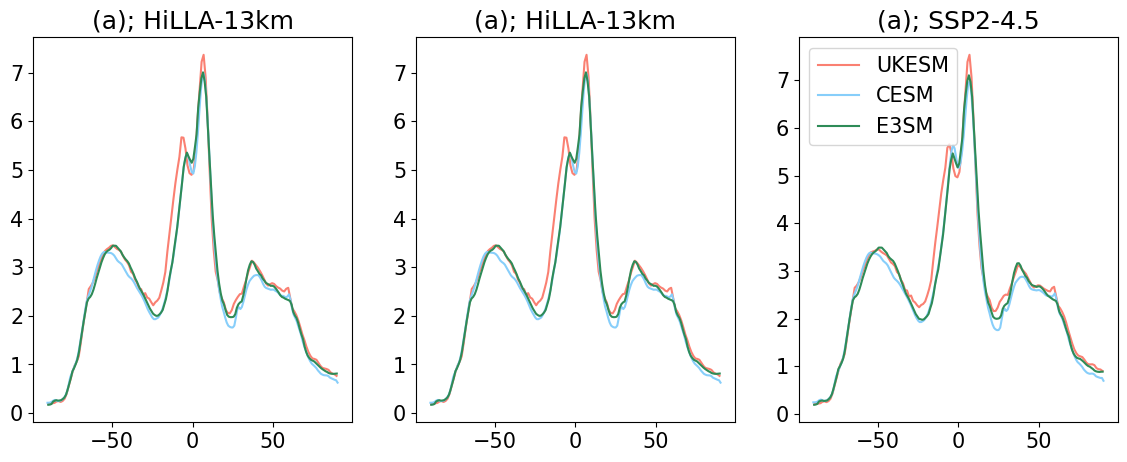

In [6]:
## plot absolute pr first, to check

fig, axs = plt.subplots(nrows=1,ncols=3,
                        figsize=(14,5))

titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

alt = '13km'

i=0
for i in [0, 1]:
    ax = axs[i]
    for model in models:
        ds = get_time_slice_mean(HiLLA_data[model][alt].mean('longitude'))
        ax.plot(ds.latitude, ds.pr, c=model_colors[model])
    ax.set_title(str(titles[0]+'; HiLLA-'+alt))    
i=i+1

ax = axs[2]
for model in models:
    ds = get_time_slice_mean(SSP245_data[model].mean(['longitude', 'Ensemble_member']))
    ax.plot(ds.latitude, ds.pr, c=model_colors[model], label=model)
ax.set_title(str(titles[0]+'; '+'SSP2-4.5'))    
ax.legend()
#plt.savefig('Figures/Precip_zonal.jpg', dpi=300)




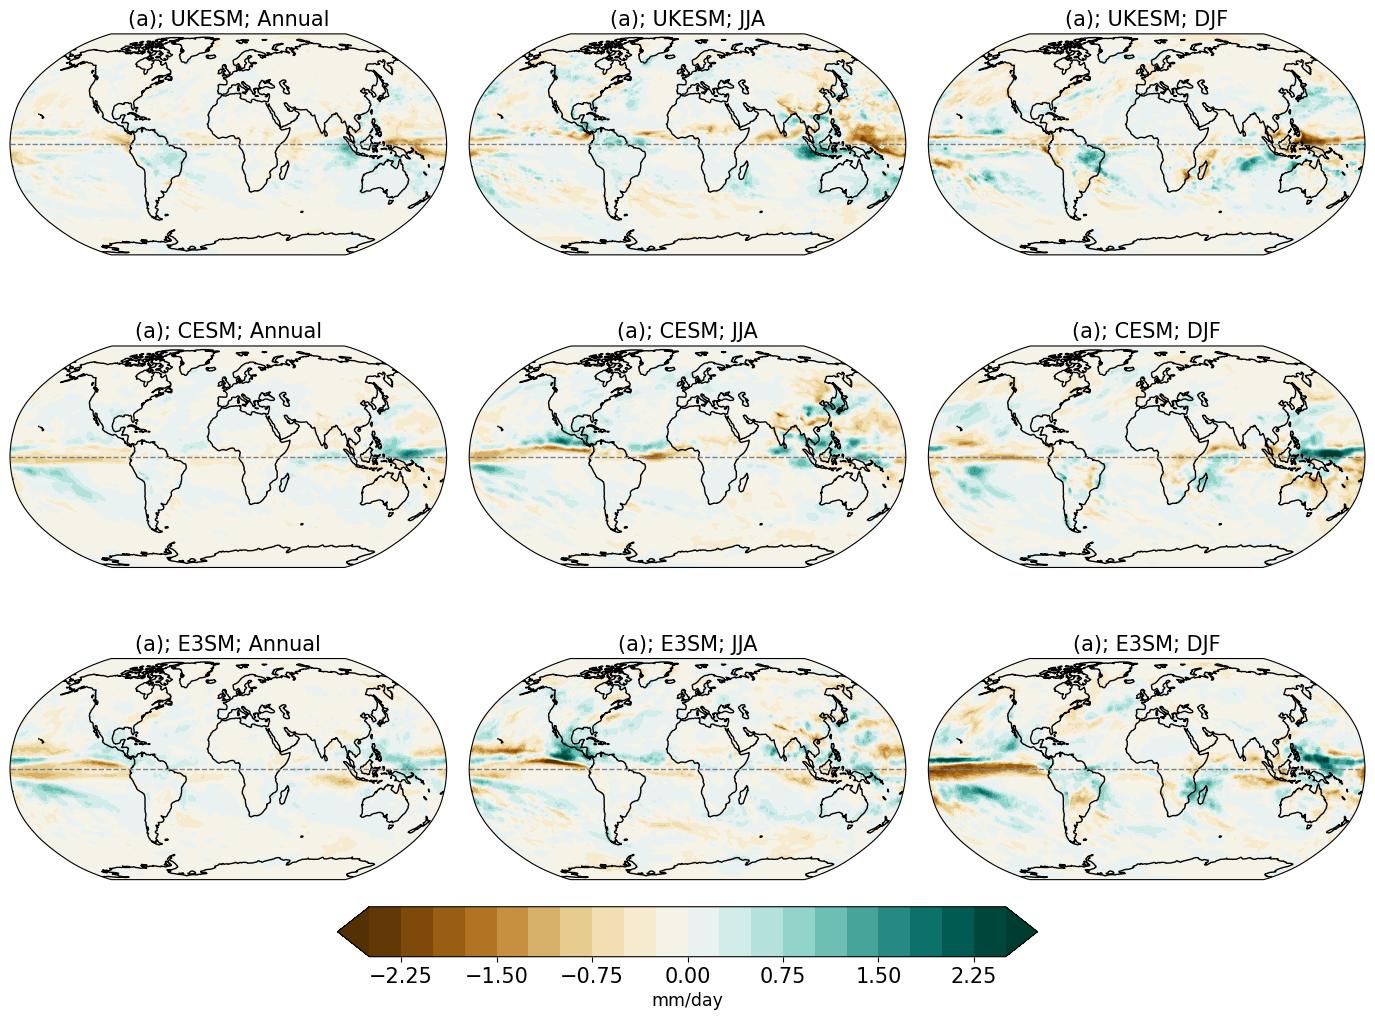

In [7]:
cols = 'BrBG'

fig, axs = plt.subplots(nrows=3,ncols=3,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(14,10))

titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

alt = '15km'

i=0
for model in models:
    for season in ['Annual', 'JJA', 'DJF']:
        ax = axs.flatten()[i]
        ds = HiLLA_pr_deltas[model][alt][season]
        data,lons=add_cyclic_point(ds,coord=ds['longitude'])
        cs=ax.contourf(lons,ds['latitude'],data,
                       levels=np.arange(-2.5, 2.6, 0.25),
                       transform = ccrs.PlateCarree(),
                       cmap=cols,
                       extend='both')
        ax.set_title(str(titles[0]+'; '+model+'; '+season), fontsize='medium')
        ax.coastlines()
        #wax.grid(ls='dotted')
        gl = ax.gridlines(crs=ccrs.Robinson(), draw_labels=False,
                  linewidth=1, color='gray', alpha=1, linestyle='--')
        gl.xlines = False
        gl.ylocator = mticker.FixedLocator([0])
        i=i+1

plt.tight_layout()
# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.25, 0, 0.5, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='horizontal')
cbar.set_label('mm/day', rotation=0, fontsize='small')
cbar.ax.yaxis.label.set_va('center')

plt.savefig('Figures/Precip_maps.jpg', dpi=300)

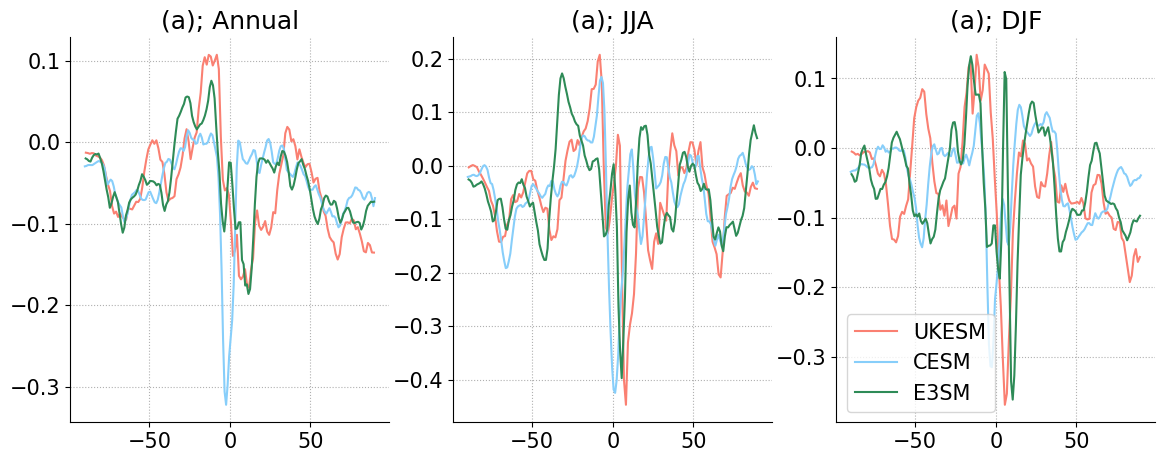

In [8]:
## now plot zonally, for abs difference

fig, axs = plt.subplots(nrows=1,ncols=3,
                        figsize=(14,5))

titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

alt = '13km'

i=0
for season in ['Annual', 'JJA', 'DJF']:
    ax = axs[i]
    for model in models:
        ds = HiLLA_pr_deltas[model][alt][season].mean('longitude')
        ax.plot(ds.latitude, ds.values, c=model_colors[model], label=model)
        #ax.
    ax.set_title(str(titles[0]+'; '+season))   
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    i=i+1
ax.legend()

plt.savefig('Figures/Precip_zonal.jpg', dpi=300)

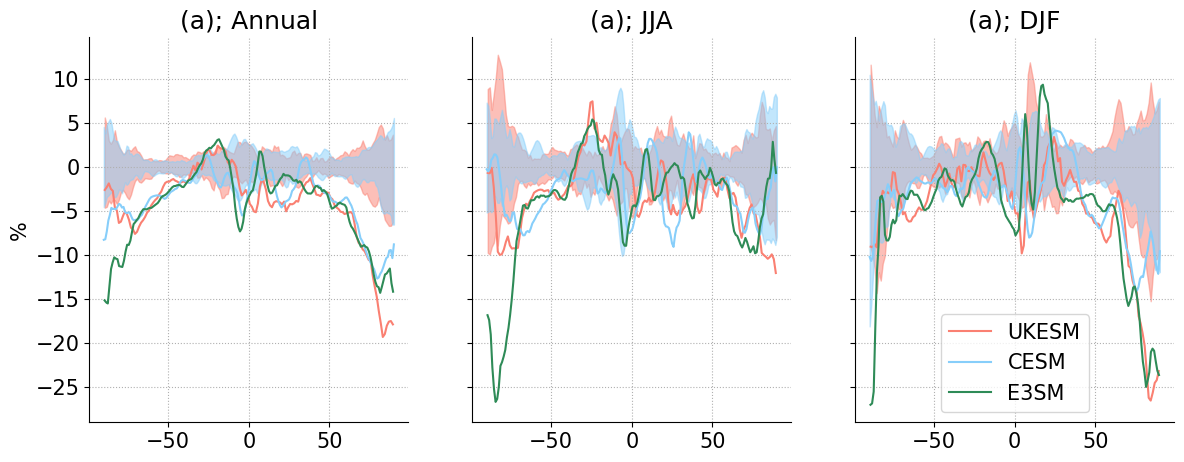

In [9]:
## now plot zonally in % 


fig, axs = plt.subplots(nrows=1,ncols=3,
                        figsize=(14,5), sharey=True)

titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

alt = '15km'

i=0
for season in ['Annual', 'JJA', 'DJF']:
    ax = axs[i]
    for model in models:
        ds = 100*HiLLA_pr_deltas[model][alt][season].mean('longitude')/SSP245_controls[model][season].mean(['longitude', 'Ensemble_member'])
        ax.plot(ds.latitude, ds.values, c=model_colors[model], label=model)

        if not model == 'E3SM':
            # also plot the variation in baseline as shaded region around zero
            max_em = 100 - (100*SSP245_controls[model][season].mean('longitude').max('Ensemble_member')/SSP245_controls[model][season].mean(['longitude', 'Ensemble_member']))
            min_em = 100 - (100*SSP245_controls[model][season].mean('longitude').min('Ensemble_member')/SSP245_controls[model][season].mean(['longitude', 'Ensemble_member']))
            ax.fill_between(max_em.latitude, max_em.values, min_em.values, color=model_colors[model], alpha=0.5)
        
    ax.set_title(str(titles[0]+'; '+season))    
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    i=i+1
axs[0].set_ylabel('%')
ax.legend()

plt.savefig('Figures/Precip_zonal_perc.jpg', dpi=300)

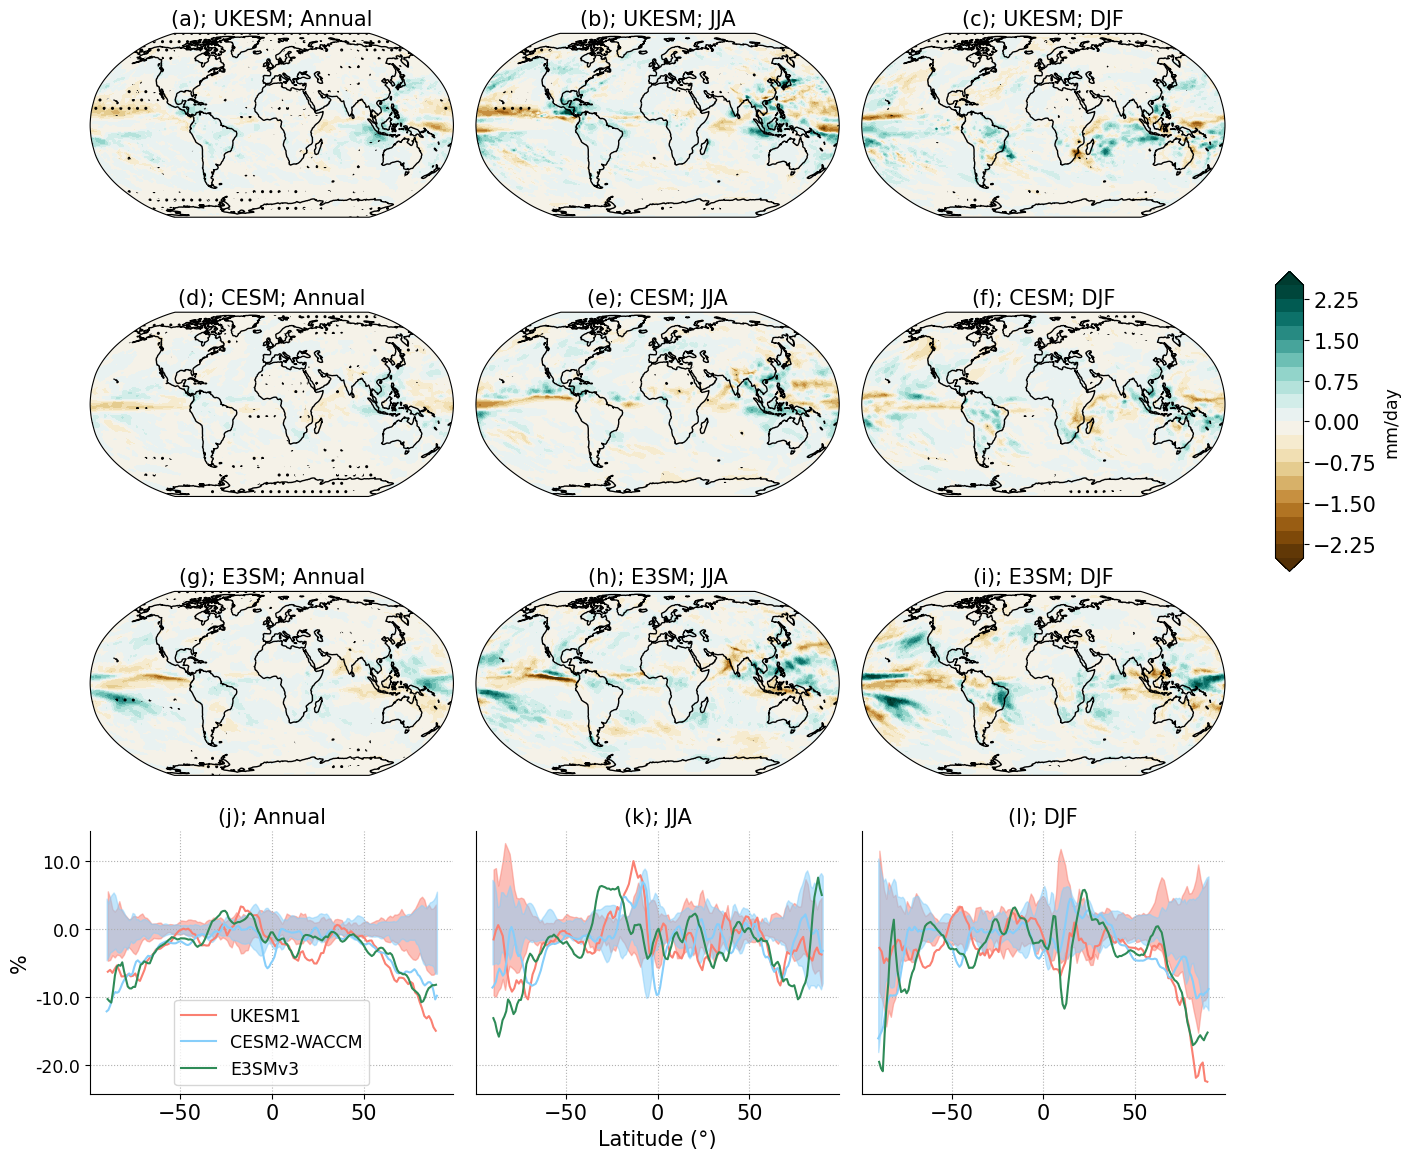

In [13]:
## v2 : now repeat the above, combining the maps and zonal means into one figure:
## we also add sig markings (Wilks FDR) this time. takes a few mins to run

### prep sig masks for figure

alt = '13km' 

from FDR_funcs import ttest_ind_from_stats_pixel, ttest_xr, welchs_ttest_array, calculate_pvalue_array, fdr_threshold
season_defs = {'Annual':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
               'JJA':[6, 7, 8],
               'DJF':[12, 1, 2]}

alpha = 0.05 # threshold for false discovery rate
seasons = ['Annual', 'JJA', 'DJF']

sig_mask_model_dicts = []
for model in models:
    sig_masks_model = []
    for season in seasons:
        ds1 = SSP245_data[model]
        ds2 = HiLLA_data[model][alt]
        
        ds1, ds2 = ds1.where(ds1.time.dt.month.isin(season_defs[season]), drop=True), ds2.where(ds2.time.dt.month.isin(season_defs[season]), drop=True)
        ds1, ds2 = ds1.groupby(ds1.time.dt.year).mean(), ds2.groupby(ds2.time.dt.year).mean()
        ds1, ds2 = ds1.sel(year=slice('2050', '2069')), ds2.sel(year=slice('2050', '2069'))
        
        var = 'pr'
        t_stat, df = welchs_ttest_array(mean1=ds1.mean(['year', 'Ensemble_member'])[var].values, 
                                    std1=ds1.std(['year', 'Ensemble_member'])[var].values,
                                    n1=np.full_like(ds1.std(['year', 'Ensemble_member'])[var].values, len(ds1.year)*len(ds1.Ensemble_member)),
                                    mean2=ds2.mean('year')[var].values, 
                                    std2=ds2.std('year')[var].values,
                                    n2=np.full_like(ds2.std('year')[var].values, len(ds2.year)))
        
        p_values = calculate_pvalue_array(t_stat, df)
        p_values_xr = ds1.mean(['year', 'Ensemble_member']).copy()
        p_values_xr[var].values = p_values
        
        p_thresh_fdr = fdr_threshold(p_values, alpha)
        sig_mask = xr.where(p_values_xr[var]<p_thresh_fdr, 1, 0)
        sig_masks_model.append(sig_mask)
    sig_mask_model_dicts.append(dict(zip(seasons, sig_masks_model)))

sig_masks_all = dict(zip(models, sig_mask_model_dicts))


cols = 'BrBG'

titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']

fig = plt.figure(figsize=(14, 12))

i = 0
for model in models:
    for season in seasons:
        ax = fig.add_subplot(4, 3, i + 1, projection=ccrs.Robinson())
        ds = HiLLA_pr_deltas[model][alt][season]
        data, lons = add_cyclic_point(ds, coord=ds['longitude'])
        
        cs = ax.contourf(lons, ds['latitude'], data,
                         levels=np.arange(-2.5, 2.6, 0.25),
                         transform=ccrs.PlateCarree(),
                         cmap=cols,
                         extend='both')
        
        sig_mask = sig_masks_all[model][season]
        sig_mask_,lons=add_cyclic_point(sig_mask, coord=sig_mask['longitude'])
        cs_hatch = ax.contourf(lons,sig_mask['latitude'],sig_mask_,
                   transform = ccrs.PlateCarree(),
                   levels=[0, 0.2, 1.2], colors='none',
                   hatches=[None,'..', '..'],
                   extend='neither', zorder=1000)
        
        ax.set_title(f'{titles[i]}; {model}; {season}', fontsize='medium')
        ax.coastlines()
        #gl = ax.gridlines(crs=ccrs.Robinson(), draw_labels=False, linewidth=2, color='black', alpha=1,)
        #gl.xlines = False
        #gl.ylocator = mticker.FixedLocator([0])
        i += 1
        
plt.tight_layout()
cbar_ax = fig.add_axes([0.92, 0.5, 0.02, 0.25])
cbar = fig.colorbar(cs, cax=cbar_ax, orientation='vertical')
cbar.set_label('mm/day', rotation=90, fontsize='small')


line_axs = []
for j, season in enumerate(['Annual', 'JJA', 'DJF']):
    if j == 0:
        ax = fig.add_subplot(4, 3, i + j + 1)
        line_axs.append(ax)
    else:
        ax = fig.add_subplot(4, 3, i + j + 1, sharey=line_axs[0])
        #ax.set_yticklabels([]) 
        ax.tick_params(axis='y', which='both', labelleft=False, left=False)
        line_axs.append(ax)

    for model in models:
        ds = 100 * HiLLA_pr_deltas[model][alt][season].mean('longitude') / SSP245_controls[model][season].mean(['longitude', 'Ensemble_member'])
        ax.plot(ds.latitude, ds.values, c=model_colors[model], label=model_names[model])
        
        if not model == 'E3SM':
            max_em = 100 - (100 * SSP245_controls[model][season].mean('longitude').max('Ensemble_member') / SSP245_controls[model][season].mean(['longitude', 'Ensemble_member']))
            min_em = 100 - (100 * SSP245_controls[model][season].mean('longitude').min('Ensemble_member') / SSP245_controls[model][season].mean(['longitude', 'Ensemble_member']))
            ax.fill_between(max_em.latitude, max_em.values, min_em.values, color=model_colors[model], alpha=0.5)
    
    ax.set_title(f'{titles[i + j]}; {season}', fontsize='medium')
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

line_axs[0].legend(loc='lower center', fontsize='small')
line_axs[0].set_ylabel('%')
ticks = line_axs[0].get_yticks()
line_axs[0].set_yticklabels(ticks, fontsize='small')
#line_axs[1].set_yticklabels([]) # hacky - for some reason they come back if i don't include this. 
#line_axs[2].set_yticklabels([]) 
line_axs[1].set_xlabel('Latitude (°)')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make space for the colorbar
plt.savefig(f'Figures/Precip_maps_and_zonals_{alt}.jpg', dpi=300, bbox_inches='tight')

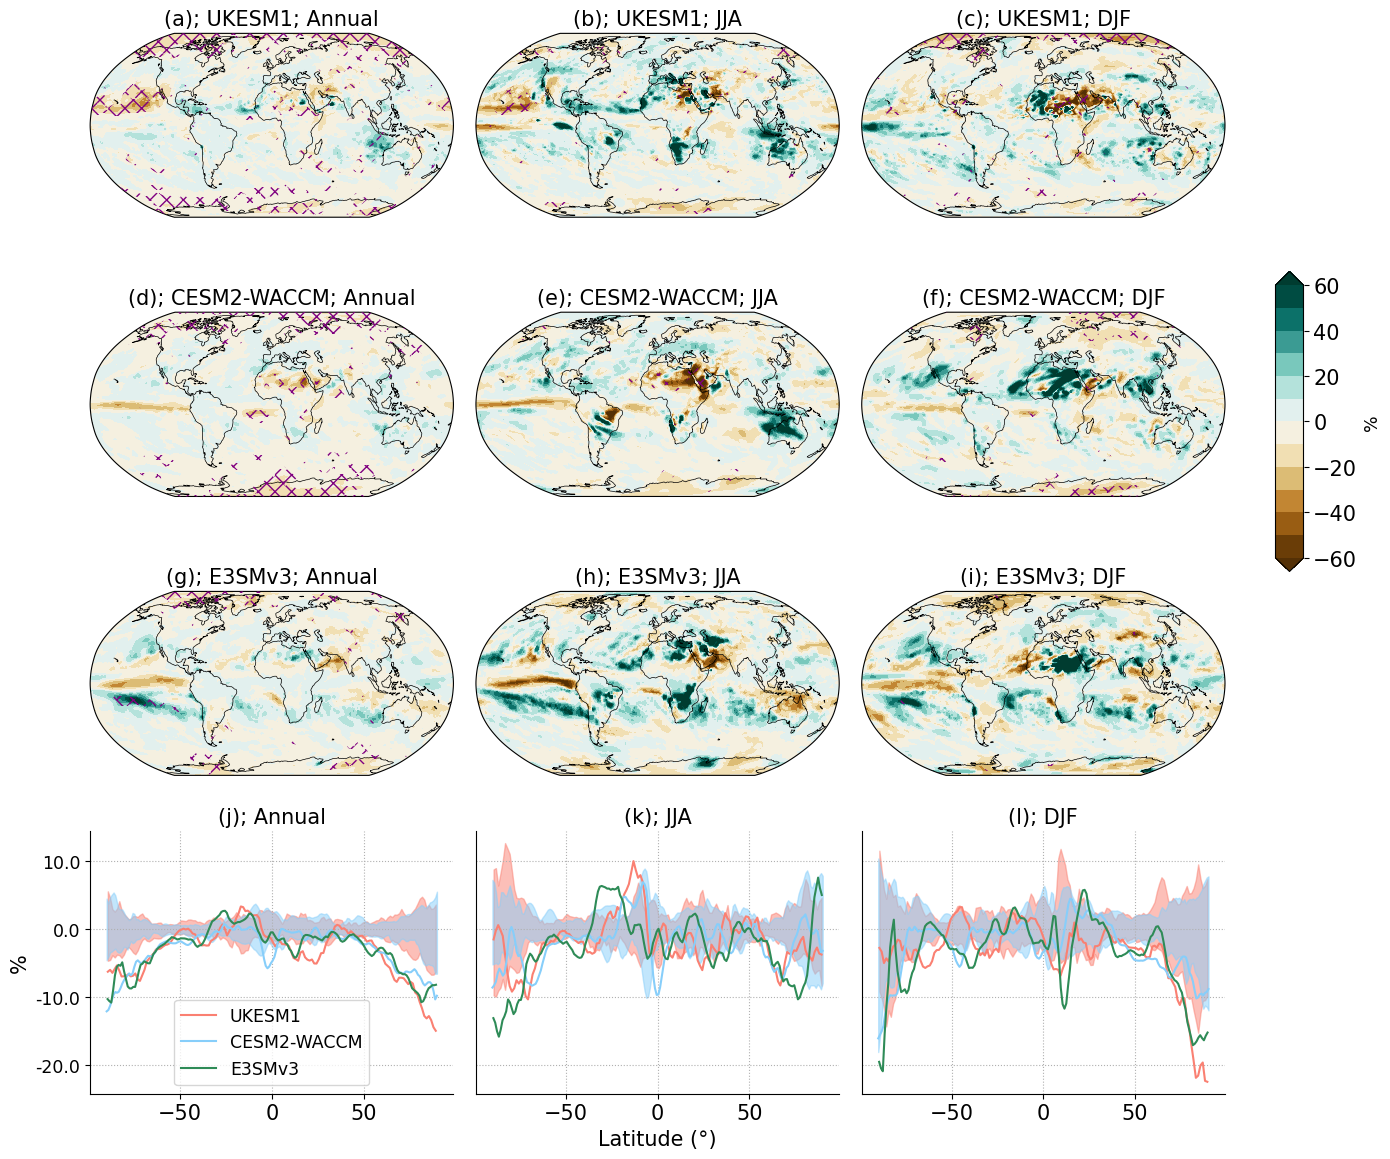

In [14]:
## to add - same as above, but with the change measured as a percentage of local pr


## Same as above, but maps (panels a-i) show precipitation change as % of local SSP2-4.5 baseline

cols = 'BrBG'

titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']

model_names = {'UKESM':'UKESM1', 'CESM':'CESM2-WACCM', 'E3SM':'E3SMv3'}
fig = plt.figure(figsize=(14, 12))

i = 0
for model in models:
    for season in seasons:
        ax = fig.add_subplot(4, 3, i + 1, projection=ccrs.Robinson())
        
        # Percentage change: HiLLA delta / SSP245 baseline * 100
        ds_abs = HiLLA_pr_deltas[model][alt][season]
        ds_ctrl = SSP245_controls[model][season].mean('Ensemble_member')
        ds = 100 * ds_abs / ds_ctrl
        
        data, lons = add_cyclic_point(ds, coord=ds['longitude'])
        
        cs = ax.contourf(lons, ds['latitude'], data,
                         levels=np.arange(-60, 61, 10),
                         transform=ccrs.PlateCarree(),
                         cmap=cols,
                         extend='both')
        
        sig_mask = sig_masks_all[model][season]
        sig_mask_, lons_sig = add_cyclic_point(sig_mask, coord=sig_mask['longitude'])
        cs_hatch = ax.contourf(lons_sig, sig_mask['latitude'], sig_mask_,
                               transform=ccrs.PlateCarree(),
                               levels=[0, 0.2, 1.2], colors='None',
                               hatches=[None, 'xx', 'xx'], 
                               extend='neither', zorder=1000)

        for collection in cs_hatch.collections:
            collection.set_edgecolor('purple') 
            collection.set_linewidth(0)
        
        ax.set_title(f'{titles[i]}; {model_names[model]}; {season}', fontsize='medium')
        ax.coastlines(linewidth=0.5)
        i += 1

plt.tight_layout()
cbar_ax = fig.add_axes([0.92, 0.5, 0.02, 0.25])
cbar = fig.colorbar(cs, cax=cbar_ax, orientation='vertical')
cbar.set_label('%', rotation=90, fontsize='small')

line_axs = []
for j, season in enumerate(['Annual', 'JJA', 'DJF']):
    if j == 0:
        ax = fig.add_subplot(4, 3, i + j + 1)
        line_axs.append(ax)
    else:
        ax = fig.add_subplot(4, 3, i + j + 1, sharey=line_axs[0])
        ax.tick_params(axis='y', which='both', labelleft=False, left=False)
        line_axs.append(ax)

    for model in models:
        ds = 100 * HiLLA_pr_deltas[model][alt][season].mean('longitude') / SSP245_controls[model][season].mean(['longitude', 'Ensemble_member'])
        ax.plot(ds.latitude, ds.values, c=model_colors[model], label=model_names[model])

        if not model == 'E3SM':
            max_em = 100 - (100 * SSP245_controls[model][season].mean('longitude').max('Ensemble_member') / SSP245_controls[model][season].mean(['longitude', 'Ensemble_member']))
            min_em = 100 - (100 * SSP245_controls[model][season].mean('longitude').min('Ensemble_member') / SSP245_controls[model][season].mean(['longitude', 'Ensemble_member']))
            ax.fill_between(max_em.latitude, max_em.values, min_em.values, color=model_colors[model], alpha=0.5)

    ax.set_title(f'{titles[i + j]}; {season}', fontsize='medium')
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

line_axs[0].legend(loc='lower center', fontsize='small')
line_axs[0].set_ylabel('%')
ticks = line_axs[0].get_yticks()
line_axs[0].set_yticklabels(ticks, fontsize='small')
line_axs[1].set_xlabel('Latitude (°)')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig(f'Figures/Precip_maps_and_zonals_{alt}_perc.jpg', dpi=250, bbox_inches='tight')